<a href="https://colab.research.google.com/github/Storm00212/Data-science-and-ml-resource/blob/main/Simple_snn_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip uninstall -y snntorch-ipu
!pip install snntorch

Found existing installation: snntorch-ipu 0.5.18
Uninstalling snntorch-ipu-0.5.18:
  Successfully uninstalled snntorch-ipu-0.5.18
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 8.0 MB/s eta 0:00:00


In [5]:
import torch, torch.nn as nn
import snntorch as snn
import snntorch.functional as SF

In [7]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

batch_size = 128
data_path='/tmp/data/mnist'

# Define a transform
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)

# Create DataLoaders
train_loader = DataLoader(dataset=mnist_train, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(dataset=mnist_test, batch_size=batch_size, shuffle=True, num_workers=2)

In [9]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        num_inputs = 28*28
        num_hidden = 1000
        num_outputs = 10

        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.LIF(beta=0.9)
        self.fc2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Flatten input
        x = x.view(x.size(0), -1)

        # Initialize hidden states
        mem1 = self.lif1.init_hidden()

        # Pass data through layers
        cur1 = self.fc1(x)
        spk1, mem1 = self.lif1(cur1, mem1)
        cur2 = self.fc2(spk1)

        return cur2

# Initialize the network
net = Net()
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=1000, bias=True)
  (lif1): LIF()
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


In [10]:
import snntorch.surrogate as surrogate

# Redefine Net to accept num_steps in forward pass
class Net(nn.Module):
    def __init__(self, num_inputs=28*28, num_hidden=1000, num_outputs=10):
        super().__init__()

        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.LIF(beta=0.9, spike_grad=surrogate.fast_sigmoid())
        self.fc2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x, num_steps):
        # Flatten input
        x = x.view(x.size(0), -1)

        # Initialize hidden states for multi-step simulation
        mem1 = self.lif1.init_hidden()
        spk_out = torch.zeros(x.size(0), self.fc2.out_features, device=x.device)

        # Simulate over `num_steps`
        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            spk_out += self.fc2(spk1) # Accumulate spikes at the output layer

        return spk_out

# Re-initialize the network with the updated class definition
net = Net()
print(net)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)


Net(
  (fc1): Linear(in_features=784, out_features=1000, bias=True)
  (lif1): LIF()
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


Net(
  (fc1): Linear(in_features=784, out_features=1000, bias=True)
  (lif1): LIF()
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)

Now, let's define the training parameters, optimizer, and loss function, and then set up the training loop.

In [11]:
import torch.optim as optim
import matplotlib.pyplot as plt

# Training Parameters
num_epochs = 10
num_steps = 25 # Number of time steps for SNN simulation
learning_rate = 1e-2

# Loss and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=learning_rate, betas=(0.9, 0.999))

# Function to calculate accuracy
def calculate_accuracy(data_loader, net, num_steps, device):
    with torch.no_grad():
        total = 0
        correct = 0
        for data, targets in data_loader:
            data = data.to(device)
            targets = targets.to(device)
            spk_out = net(data, num_steps)
            _, predicted = spk_out.max(1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    return 100 * correct / total


# Training Loop
loss_hist = []
train_accuracy_hist = []
test_accuracy_hist = []

print("Starting training...")
for epoch in range(num_epochs):
    for i, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = targets.to(device)

        # Forward pass
        spk_out = net(data, num_steps)

        # Calculate loss
        loss = loss_fn(spk_out, targets)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_hist.append(loss.item())

    # Evaluate accuracy after each epoch
    train_accuracy = calculate_accuracy(train_loader, net, num_steps, device)
    test_accuracy = calculate_accuracy(test_loader, net, num_steps, device)
    train_accuracy_hist.append(train_accuracy)
    test_accuracy_hist.append(test_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: Loss = {loss.item():.4f}, Train Accuracy = {train_accuracy:.2f}%, Test Accuracy = {test_accuracy:.2f}%")

print("Training complete.")

Starting training...


TypeError: 'bool' object is not callable

Let's visualize the training loss and accuracy over epochs.

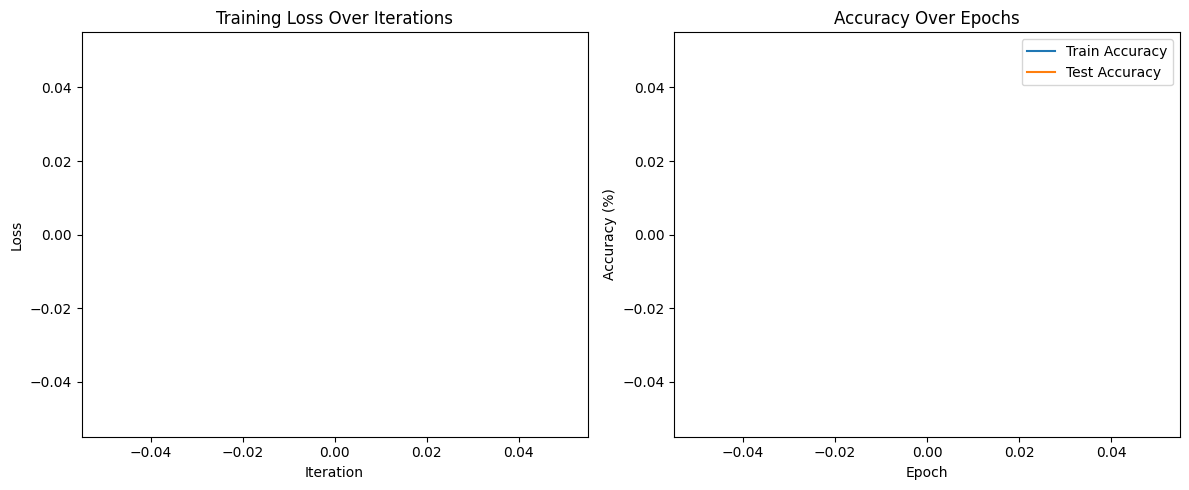

In [12]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(loss_hist)
plt.title('Training Loss Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracy_hist, label='Train Accuracy')
plt.plot(test_accuracy_hist, label='Test Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()